# 06. Weather Grid Feature Lab: 공간 평균에서 분포 통계로

> 작성일: 2026-07-17 KST  
> 연구 질문: 공식 `mean` baseline과 `mean + std(ddof=0) + min + max + lead`가 동일한 2024 time holdout에서 어떤 차이를 만드는가?

이 노트북은 데이터 파악과 전처리/가공 증거를 가장 두껍게 남긴다. 원시 데이터는 읽기 전용이며 모델·registry·submission·`outputs/` 파일을 만들지 않는다. Group 3 결측 label은 0으로 대체하지 않고 target별 non-null mask를 사용한다. actual은 원본을 유지하고 prediction만 capacity 범위로 clip한다.

## 벤치마킹 융합표

| 근거 | 이어받는 원칙 | 이번 검증 |
|---|---|---|
| 공식 baseline | source별 numeric mean, calendar, train-fit median, target별 RF | mean-only 비교군 74개 feature 재현 |
| 04 설계서 | mean이 버리는 공간 분포를 std/min/max로 보완 | 확장안 271개 feature |
| 05 registry 노트북 | 증거 사다리와 5단계 분석, preprocessing schema 잠금 | grid·lead·결측·schema를 모델보다 먼저 검증 |
| 외부 3조/EDA 방법론 | 연구 질문 → 전후 비교 → Decision Box → 강건성 → 결론 | 각 code 뒤 관찰 → 해석 → 다음 판단 기록 |

## 전문가 방법론: 5단계와 증거 사다리

1. 데이터 파악: 행 수, 기간, source별 grid, lead, cutoff, 결측을 잠근다.
2. 데이터 전처리/가공: metadata와 수치 weather를 분리하고 feature 이름·순서·ddof·all-NaN·imputer 계약을 잠근다.
3. 속성 탐색: feature family와 target별 학습 가용성을 확인한다.
4. 시각화: 공간 범위와 결측 위치를 눈으로 검증한다.
5. 해석과 의사결정: 동일 모델·seed·mask·metric·clip 조건에서만 비교한다.

앞 단계의 계약이 실패하면 뒤 단계 성능을 의사결정 근거로 승격하지 않는다.

In [1]:
from pathlib import Path
import hashlib
import json
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))

from baram.baseline import (
  OFFICIAL_RF_PARAMS,
  calendar_features,
  predict_random_forest_baseline,
  train_random_forest_baseline,
)
from baram.features.weather_grid import (
  SPATIAL_STATISTICS,
  build_weather_feature_pair,
  fit_train_median_imputer,
)
from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "open"
ARTIFACT_ROOTS = [
  PROJECT_ROOT / "outputs",
  PROJECT_ROOT / "submissions",
  PROJECT_ROOT / "models",
]
GUARDED_ARTIFACT_PATTERNS = [
  "*.pkl",
  "*.pickle",
  "*.joblib",
  "*registry*.csv",
  "*submission*.csv",
]

def snapshotArtifactFiles():
  return sorted(
    str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
    for root in ARTIFACT_ROOTS
    if root.exists()
    for path in root.rglob("*")
    if path.is_file() and path.name != ".gitkeep"
  )

def snapshotGuardedArtifacts():
  guarded = set()
  for pattern in GUARDED_ARTIFACT_PATTERNS:
    for path in PROJECT_ROOT.rglob(pattern):
      relativePath = str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
      if path.is_file() and not relativePath.startswith("data/raw/open/"):
        guarded.add(relativePath)
  return sorted(guarded)

artifactFilesBefore = snapshotArtifactFiles()
guardedArtifactsBefore = snapshotGuardedArtifacts()
pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")
display({
  "project_root": str(PROJECT_ROOT),
  "python": sys.version.split()[0],
  "raw_read_only": True,
  "artifact_files_before": artifactFilesBefore,
  "guarded_artifacts_before": guardedArtifactsBefore,
  "rf_params": OFFICIAL_RF_PARAMS,
})

{'project_root': 'C:\\Users\\kik32\\workspace\\Dacon\\2026-BARAM-Wind-Power-Prediction-AI-Competition',
 'python': '3.12.13',
 'raw_read_only': True,
 'artifact_files_before': [],
 'guarded_artifacts_before': [],
 'rf_params': {'n_estimators': 120,
  'max_depth': 14,
  'min_samples_leaf': 8,
  'max_features': 'sqrt',
  'random_state': 42,
  'n_jobs': -1}}

## TDD RED 실행 증거

구현 전에 필수 metadata 누락, cutoff 위반, LDAPS 16/GFS 9 grid 계약 위반, 동일 forecast lead 불일치, 숫자형 weather 부재, train/test 이름·순서 drift, all-grid NaN 은폐, source prefix 충돌·중복 이름을 실패 사례로 고정했다.

- RED 명령: `python -m pytest tests/test_weather_features.py -q`
- RED 결과: **14 failed in 2.55s**
- 실패 원인: 구현 로직이 없는 명시적 `NotImplementedError` 스텁에 대해 14개 수집 사례가 모두 실패했다. 따라서 기존 코드가 우연히 통과한 것이 아니라 새 계약이 실제로 RED임을 확인했다.

In [2]:
redEvidence = pd.DataFrame([
  ("필수 metadata", "누락 컬럼 즉시 실패", 1),
  ("availability cutoff", "available > forecast 즉시 실패", 1),
  ("source grid", "LDAPS 16 / GFS 9 exact", 2),
  ("forecast lead", "동일 forecast 내부 단일값", 1),
  ("numeric weather", "수치 변수 부재 즉시 실패", 1),
  ("train/test schema", "이름 drift와 순서 drift 각각 실패", 2),
  ("all-grid NaN", "mean/std/min/max NaN 보존", 1),
  ("prefix/duplicate", "source 충돌과 중복 이름 실패", 2),
  ("결정성/fit 범위", "ddof·정렬·train median 계약", 3),
], columns=["계약군", "RED 기대", "수집 사례"])
display(redEvidence)
print("RED: python -m pytest tests/test_weather_features.py -q")
print("결과: 14 failed in 2.55s")

,계약군,RED 기대,수집 사례
0,필수 metadata,누락 컬럼 즉시 실패,1
1,availability cutoff,available > forecast 즉시 실패,1
2,source grid,LDAPS 16 / GFS 9 exact,2
3,forecast lead,동일 forecast 내부 단일값,1
4,numeric weather,수치 변수 부재 즉시 실패,1
5,train/test schema,이름 drift와 순서 drift 각각 실패,2
6,all-grid NaN,mean/std/min/max NaN 보존,1
7,prefix/duplicate,source 충돌과 중복 이름 실패,2
8,결정성/fit 범위,ddof·정렬·train median 계약,3


RED: python -m pytest tests/test_weather_features.py -q
결과: 14 failed in 2.55s


## 1단계. 데이터 파악: 원시 forecast 계약

파일 inventory와 source별 행·열·기간·forecast 수를 먼저 확인한다. 이 단계에서는 raw 값을 수정하거나 결측을 채우지 않는다.

In [3]:
inputPaths = {
  "train_labels": DATA_ROOT / "train" / "train_labels.csv",
  "ldaps_train": DATA_ROOT / "train" / "ldaps_train.csv",
  "gfs_train": DATA_ROOT / "train" / "gfs_train.csv",
  "ldaps_test": DATA_ROOT / "test" / "ldaps_test.csv",
  "gfs_test": DATA_ROOT / "test" / "gfs_test.csv",
  "sample_submission": DATA_ROOT / "sample_submission.csv",
}
frames = {
  name: pd.read_csv(path, encoding="utf-8-sig")
  for name, path in inputPaths.items()
}
trainLabels = frames["train_labels"].copy()
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"], errors="raise")
sampleSubmission = frames["sample_submission"].copy()
sampleSubmission["forecast_kst_dtm"] = pd.to_datetime(
  sampleSubmission["forecast_kst_dtm"], errors="raise"
)
weatherFrames = {
  name: frames[name]
  for name in ["ldaps_train", "gfs_train", "ldaps_test", "gfs_test"]
}
inventoryRows = []
for name, frame in frames.items():
  timeColumn = "kst_dtm" if name == "train_labels" else "forecast_kst_dtm"
  timestamps = pd.to_datetime(frame[timeColumn], errors="raise")
  inventoryRows.append({
    "file": name,
    "rows": len(frame),
    "columns": len(frame.columns),
    "start_kst": timestamps.min(),
    "end_kst": timestamps.max(),
    "bytes": inputPaths[name].stat().st_size,
  })
inventory = pd.DataFrame(inventoryRows)
display(inventory)

,file,rows,columns,start_kst,end_kst,bytes
0,train_labels,26304,4,2022-01-01 01:00:00,2025-01-01,1138967
1,ldaps_train,420864,35,2022-01-01 01:00:00,2025-01-01,129687357
2,gfs_train,236736,40,2022-01-01 01:00:00,2025-01-01,84315594
3,ldaps_test,140160,35,2025-01-01 01:00:00,2026-01-01,43122637
4,gfs_test,78840,40,2025-01-01 01:00:00,2026-01-01,28037722
5,sample_submission,8760,5,2025-01-01 01:00:00,2026-01-01,359229


### 관찰 → 해석 → 다음 판단

관찰: train weather와 label은 2022-01-01 01:00부터 2025-01-01 00:00까지 26,304 forecast 시각이고, test는 2025년 8,760시간이다. LDAPS/GFS raw 행 수는 각각 forecast 수의 16배/9배다.  
해석: 공식 명세의 시간축과 파일 크기를 재현했으며, row-level 격자 검증을 수행할 전제가 충족됐다.  
다음 판단: 단순 shape 일치만으로 통과시키지 않고 grid 중복, lead, cutoff, all-grid NaN을 전수 검사한다.

In [4]:
METADATA_COLUMNS = [
  "forecast_kst_dtm",
  "data_available_kst_dtm",
  "grid_id",
  "latitude",
  "longitude",
]
allGridNanRows = []
sourceRows = []
for name, frame in weatherFrames.items():
  forecast = pd.to_datetime(frame["forecast_kst_dtm"], errors="raise")
  available = pd.to_datetime(frame["data_available_kst_dtm"], errors="raise")
  leadHour = (forecast - available).dt.total_seconds().div(3600)
  working = frame.assign(_forecast=forecast, _lead=leadHour)
  grouped = working.groupby("_forecast", sort=True)
  numericColumns = [
    column for column in frame.columns
    if column not in METADATA_COLUMNS and pd.api.types.is_numeric_dtype(frame[column])
  ]
  groupCounts = grouped[numericColumns].count()
  allGridNanMask = groupCounts.eq(0)
  for forecastTime, column in zip(*np.where(allGridNanMask.to_numpy())):
    allGridNanRows.append({
      "source": name,
      "forecast_kst_dtm": allGridNanMask.index[forecastTime],
      "raw_feature": allGridNanMask.columns[column],
    })
  gridCount = grouped["grid_id"].nunique()
  rowCount = grouped.size()
  sourceRows.append({
    "source": name,
    "rows": len(frame),
    "forecast_rows": forecast.nunique(),
    "grid_min": gridCount.min(),
    "grid_max": gridCount.max(),
    "rows_per_forecast_min": rowCount.min(),
    "rows_per_forecast_max": rowCount.max(),
    "lead_min": leadHour.min(),
    "lead_max": leadHour.max(),
    "lead_unique": leadHour.nunique(),
    "inconsistent_lead_forecasts": grouped["_lead"].nunique().ne(1).sum(),
    "cutoff_violations": (available > forecast).sum(),
    "numeric_features": len(numericColumns),
    "missing_cells": frame[numericColumns].isna().sum().sum(),
    "missing_rate": frame[numericColumns].isna().sum().sum()
      / (len(frame) * len(numericColumns)),
    "all_grid_nan_pairs": allGridNanMask.sum().sum(),
    "all_grid_nan_pair_rate": allGridNanMask.sum().sum()
      / (forecast.nunique() * len(numericColumns)),
  })
sourceAudit = pd.DataFrame(sourceRows)
allGridNanDetails = pd.DataFrame(allGridNanRows)
schemaAudit = pd.DataFrame([
  {
    "source": source,
    "train_test_name_order_equal": list(frames[f"{source}_train"].columns)
      == list(frames[f"{source}_test"].columns),
  }
  for source in ["ldaps", "gfs"]
])
display(sourceAudit)
display(schemaAudit)
display(
  allGridNanDetails.groupby(["source", "forecast_kst_dtm"])
  .size().rename("all_grid_nan_features").reset_index()
)

,source,rows,forecast_rows,grid_min,grid_max,rows_per_forecast_min,rows_per_forecast_max,lead_min,lead_max,lead_unique,inconsistent_lead_forecasts,cutoff_violations,numeric_features,missing_cells,missing_rate,all_grid_nan_pairs,all_grid_nan_pair_rate
0,ldaps_train,420864,26304,16,16,16,16,12.0,35.0,24,0,0,30,0,0.000000,0,0.000000
1,gfs_train,236736,26304,9,9,9,9,12.0,35.0,24,0,0,35,0,0.000000,0,0.000000
2,ldaps_test,140160,8760,16,16,16,16,12.0,35.0,24,0,0,30,752,0.000179,47,0.000179
3,gfs_test,78840,8760,9,9,9,9,12.0,35.0,24,0,0,35,0,0.000000,0,0.000000


,source,train_test_name_order_equal
0,ldaps,True
1,gfs,True


,source,forecast_kst_dtm,all_grid_nan_features
0,ldaps_test,2025-04-08 17:00:00,14
1,ldaps_test,2025-06-18 18:00:00,14
2,ldaps_test,2025-07-18 06:00:00,19


### 관찰 → 해석 → 다음 판단

관찰: 네 source/split 모두 cutoff 위반과 forecast 내부 lead 불일치가 0이며 lead는 12~35시간이다. LDAPS는 항상 16개, GFS는 항상 9개 grid다. train weather와 GFS test는 결측률 0이지만 LDAPS test는 752개 raw 결측(수치 cell 기준 약 0.0179%), 3개 시각의 47개 variable-forecast all-grid NaN이 있다.  
해석: grid/lead 계약은 승격할 수 있지만 test 결측을 정상값 0으로 보는 것은 금지해야 한다. 네 통계로 확장하면 해당 47개 결측이 188개 집계 결측으로 드러나는 것이 올바른 동작이다.  
다음 판단: aggregation은 NaN을 보존하고, train-fit median 이전과 이후 결측 수를 둘 다 기록한다.

In [5]:
forecastYear = trainLabels["kst_dtm"].dt.year
modelTrainMask = forecastYear < 2024
holdoutMask = forecastYear == 2024
boundaryExcludedMask = forecastYear > 2024
splitAudit = pd.DataFrame([
  {
    "split": "train_2022_2023",
    "rows": int(modelTrainMask.sum()),
    "start_kst": trainLabels.loc[modelTrainMask, "kst_dtm"].min(),
    "end_kst": trainLabels.loc[modelTrainMask, "kst_dtm"].max(),
  },
  {
    "split": "holdout_2024",
    "rows": int(holdoutMask.sum()),
    "start_kst": trainLabels.loc[holdoutMask, "kst_dtm"].min(),
    "end_kst": trainLabels.loc[holdoutMask, "kst_dtm"].max(),
  },
  {
    "split": "excluded_boundary",
    "rows": int(boundaryExcludedMask.sum()),
    "start_kst": trainLabels.loc[boundaryExcludedMask, "kst_dtm"].min(),
    "end_kst": trainLabels.loc[boundaryExcludedMask, "kst_dtm"].max(),
  },
])
targetRows = []
for target in TARGET_COLS:
  actual = trainLabels[target]
  targetRows.append({
    "target": target,
    "all_non_null": actual.notna().sum(),
    "all_missing": actual.isna().sum(),
    "train_non_null": actual.loc[modelTrainMask].notna().sum(),
    "holdout_non_null": actual.loc[holdoutMask].notna().sum(),
    "holdout_metric_rows": (actual.loc[holdoutMask] >= CAPACITY_KWH[target] * 0.10).sum(),
    "capacity_exceedance": (actual > CAPACITY_KWH[target]).sum(),
  })
targetAudit = pd.DataFrame(targetRows)
assert int(modelTrainMask.sum() + holdoutMask.sum() + boundaryExcludedMask.sum()) == len(trainLabels)
assert int(boundaryExcludedMask.sum()) == 1
display(splitAudit)
display(targetAudit)

,split,rows,start_kst,end_kst
0,train_2022_2023,17519,2022-01-01 01:00:00,2023-12-31 23:00:00
1,holdout_2024,8784,2024-01-01 00:00:00,2024-12-31 23:00:00
2,excluded_boundary,1,2025-01-01 00:00:00,2025-01-01 00:00:00


,target,all_non_null,all_missing,train_non_null,holdout_non_null,holdout_metric_rows,capacity_exceedance
0,kpx_group_1,26200,104,17421,8778,4989,0
1,kpx_group_2,26201,103,17422,8778,4976,0
2,kpx_group_3,17538,8766,8759,8778,4566,38


## Decision Box 1. 원시 입력 승격 조건

| 결정 항목 | 채택 계약 | 실패 시 동작 |
|---|---|---|
| metadata | 5개 필수 컬럼 | 즉시 실패 |
| grid | LDAPS 16, GFS 9, 중복 없음 | 즉시 실패 |
| lead/cutoff | forecast 내부 단일 lead, available ≤ forecast | 즉시 실패 |
| all-grid NaN | 집계 NaN과 진단 수를 보존 | train-fit median 이전 은폐 금지 |
| label | target별 non-null mask | Group 3의 2022 결측을 0 대체 금지 |

## 2단계. 데이터 전처리/가공: schema를 먼저 잠근다

source 순서는 LDAPS → GFS, raw 변수 순서는 공식 파일 순서, 통계 순서는 mean → std → min → max로 고정한다. std는 주어진 전체 grid를 모집단으로 보고 `ddof=0`을 사용한다.

In [6]:
featureBuildStarted = time.perf_counter()
meanPair = build_weather_feature_pair(
  frames["ldaps_train"],
  frames["gfs_train"],
  frames["ldaps_test"],
  frames["gfs_test"],
  statistics=("mean",),
  include_lead=False,
)
expandedPair = build_weather_feature_pair(
  frames["ldaps_train"],
  frames["gfs_train"],
  frames["ldaps_test"],
  frames["gfs_test"],
  statistics=SPATIAL_STATISTICS,
  include_lead=True,
  std_ddof=0,
)
featureBuildSeconds = time.perf_counter() - featureBuildStarted

def buildModelMatrix(timeSeries, weatherFeatures):
  base = pd.DataFrame({"forecast_kst_dtm": pd.to_datetime(timeSeries)})
  merged = base.merge(
    weatherFeatures,
    on="forecast_kst_dtm",
    how="left",
    sort=False,
    validate="one_to_one",
  )
  if len(merged) != len(base):
    raise ValueError("시간축과 weather feature 행 수가 다릅니다")
  return pd.concat([
    calendar_features(merged["forecast_kst_dtm"]),
    merged.drop(columns=["forecast_kst_dtm"]),
  ], axis=1)

meanX = buildModelMatrix(trainLabels["kst_dtm"], meanPair.train)
expandedX = buildModelMatrix(trainLabels["kst_dtm"], expandedPair.train)
meanTestX = buildModelMatrix(sampleSubmission["forecast_kst_dtm"], meanPair.test)
expandedTestX = buildModelMatrix(sampleSubmission["forecast_kst_dtm"], expandedPair.test)
assert list(meanX.columns) == list(meanTestX.columns)
assert list(expandedX.columns) == list(expandedTestX.columns)
assert meanX.shape == (26304, 74)
assert expandedX.shape == (26304, 271)

def schemaSha256(columns):
  payload = json.dumps(list(columns), ensure_ascii=False, separators=(",", ":"))
  return hashlib.sha256(payload.encode("utf-8")).hexdigest()

featureSchema = pd.DataFrame([
  {
    "feature_set": "official_mean",
    "weather_features": len(meanPair.feature_columns),
    "calendar_features": 9,
    "model_features": meanX.shape[1],
    "statistics": "mean",
    "lead": False,
    "std_ddof": None,
    "schema_sha256": schemaSha256(meanX.columns),
  },
  {
    "feature_set": "expanded_spatial",
    "weather_features": len(expandedPair.feature_columns),
    "calendar_features": 9,
    "model_features": expandedX.shape[1],
    "statistics": "mean,std,min,max",
    "lead": True,
    "std_ddof": 0,
    "schema_sha256": schemaSha256(expandedX.columns),
  },
])
display(featureSchema)
print(f"feature build seconds: {featureBuildSeconds:.3f}")

,feature_set,weather_features,calendar_features,model_features,statistics,lead,std_ddof,schema_sha256
0,official_mean,65,9,74,mean,False,NaN,7165ab3f8b117f90d9bbc033b2d3247bcf48d098938320...
1,expanded_spatial,262,9,271,"mean,std,min,max",True,0.0,5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...


feature build seconds: 2.948


### 관찰 → 해석 → 다음 판단

관찰: forecast key를 제외한 weather feature는 mean 65개, expanded 262개이며 calendar 9개 결합 후 정확히 74개와 271개다. 두 세트는 서로 다른 schema hash를 갖고 train/test 내부 이름·순서는 완전히 같다.  
해석: 현재 `baseline.py`의 76개(mean+lead)와 분리해 공식 74개 비교군을 정확히 재현했다. 확장안의 유일한 설계 차이는 네 공간 통계와 source별 lead다.  
다음 판단: 집계 결측이 imputer 전에 보존되는지, imputer가 holdout/test를 보지 않고 train에만 fit되는지 확인한다.

In [7]:
imputerAuditRows = []
imputerObjects = {}
for featureSet, fullX, testX in [
  ("official_mean", meanX, meanTestX),
  ("expanded_spatial", expandedX, expandedTestX),
]:
  trainX = fullX.loc[modelTrainMask]
  holdoutX = fullX.loc[holdoutMask]
  fittedImputer = fit_train_median_imputer(trainX)
  imputerObjects[featureSet] = fittedImputer
  transformedHoldout = fittedImputer.transform(holdoutX)
  transformedTest = fittedImputer.transform(testX)
  medianPayload = np.asarray(fittedImputer.statistics_, dtype=float).tobytes()
  imputerAuditRows.append({
    "feature_set": featureSet,
    "fit_rows": len(trainX),
    "fit_scope": "2022-2023 train only",
    "train_missing_before": int(trainX.isna().sum().sum()),
    "holdout_missing_before": int(holdoutX.isna().sum().sum()),
    "test_missing_before": int(testX.isna().sum().sum()),
    "holdout_missing_after": int(transformedHoldout.isna().sum().sum()),
    "test_missing_after": int(transformedTest.isna().sum().sum()),
    "median_sha256": hashlib.sha256(medianPayload).hexdigest(),
  })
  del transformedHoldout, transformedTest
imputerAudit = pd.DataFrame(imputerAuditRows)
assert imputerAudit["test_missing_before"].tolist() == [47, 188]
assert imputerAudit["test_missing_after"].eq(0).all()
display(imputerAudit)

,feature_set,fit_rows,fit_scope,train_missing_before,holdout_missing_before,test_missing_before,holdout_missing_after,test_missing_after,median_sha256
0,official_mean,17519,2022-2023 train only,0,0,47,0,0,09a934257627d37e1bd3b8751d5b71fd66ddcc83c5d6aa...
1,expanded_spatial,17519,2022-2023 train only,0,0,188,0,0,ce8f26a9be7e6b0585190e43d91da791925cde247687bd...


## Decision Box 2. 전처리 계약

두 feature set은 통계 구성 외에는 timestamp 정렬, calendar, split, imputer fit 범위가 같다. mean은 test에서 47개, expanded는 188개 결측을 집계 단계에 그대로 노출했고, 2022-2023 train에만 fit한 median transform 후 0개가 됐다. test는 transform에만 사용하며 schema 이름 또는 순서 drift는 재정렬로 숨기지 않고 실패시킨다.

## 3단계. 속성 탐색: 공간 분포가 추가한 정보

mean이 보지 못하는 std와 min-max range의 크기, source별 feature family, target별 학습 행 수를 요약한다.

In [8]:
calendarColumnSet = set(calendar_features(trainLabels["kst_dtm"]).columns)
familyRows = []
for featureSet, columns in [
  ("official_mean", meanX.columns),
  ("expanded_spatial", expandedX.columns),
]:
  familyRows.append({
    "feature_set": featureSet,
    "calendar": sum(column in calendarColumnSet for column in columns),
    "mean": sum(column.endswith("_mean") for column in columns),
    "std": sum(column.endswith("_std") for column in columns),
    "min": sum(column.endswith("_min") for column in columns),
    "max": sum(column.endswith("_max") for column in columns),
    "lead": sum(column.endswith("_lead_hour") for column in columns),
  })
featureFamilies = pd.DataFrame(familyRows)

propertyFrame = trainLabels.rename(columns={"kst_dtm": "forecast_kst_dtm"}).merge(
  expandedPair.train,
  on="forecast_kst_dtm",
  how="left",
  validate="one_to_one",
)
representativeVariables = [
  ("ldaps", "heightAboveGround_10_10u"),
  ("gfs", "heightAboveGround_100_100u"),
]
spreadRows = []
for source, rawVariable in representativeVariables:
  prefix = f"{source}_{rawVariable}"
  spatialRange = propertyFrame[f"{prefix}_max"] - propertyFrame[f"{prefix}_min"]
  correlations = {
    target: propertyFrame[[f"{prefix}_std", target]].corr().iloc[0, 1]
    for target in TARGET_COLS
  }
  spreadRows.append({
    "source": source,
    "raw_variable": rawVariable,
    "std_median": propertyFrame[f"{prefix}_std"].median(),
    "std_p95": propertyFrame[f"{prefix}_std"].quantile(0.95),
    "range_median": spatialRange.median(),
    "range_p95": spatialRange.quantile(0.95),
    **{f"corr_{target}": value for target, value in correlations.items()},
  })
spreadSummary = pd.DataFrame(spreadRows)
display(featureFamilies)
display(spreadSummary)
display(targetAudit[["target", "train_non_null", "holdout_non_null", "holdout_metric_rows"]])

,feature_set,calendar,mean,std,min,max,lead
0,official_mean,9,65,0,0,0,0
1,expanded_spatial,9,65,65,65,65,2


,source,raw_variable,std_median,std_p95,range_median,range_p95,corr_kpx_group_1,corr_kpx_group_2,corr_kpx_group_3
0,ldaps,heightAboveGround_10_10u,0.731193,1.596026,2.444092,5.360071,0.400013,0.391137,0.347867
1,gfs,heightAboveGround_100_100u,1.083035,2.864190,3.470000,9.100000,0.134754,0.151717,0.168863


,target,train_non_null,holdout_non_null,holdout_metric_rows
0,kpx_group_1,17421,8778,4989
1,kpx_group_2,17422,8778,4976
2,kpx_group_3,8759,8778,4566


### 관찰 → 해석 → 다음 판단

관찰: expanded에는 source별 65개씩의 std/min/max 계열이 추가되고 대표 바람 변수의 std와 range는 0이 아닌 넓은 분포를 가진다. Group 3 train 행은 구조적 결측 때문에 Group 1/2보다 적다.  
해석: 공간 분포 정보 자체는 실제로 존재하며 mean의 단순 복제가 아니다. 그러나 상관과 산포는 예측 기여를 보장하지 않으며 feature 수가 3.66배로 늘어난 비용도 있다.  
다음 판단: 동일 RF와 target별 mask를 유지한 holdout 점수로만 승격 여부를 정한다.

## 4단계. 시각화: mean 주변의 공간 범위와 결측 위치

대표 바람 변수의 min-mean-max envelope와 lead, LDAPS test all-grid NaN 시각을 시각적으로 확인한다.

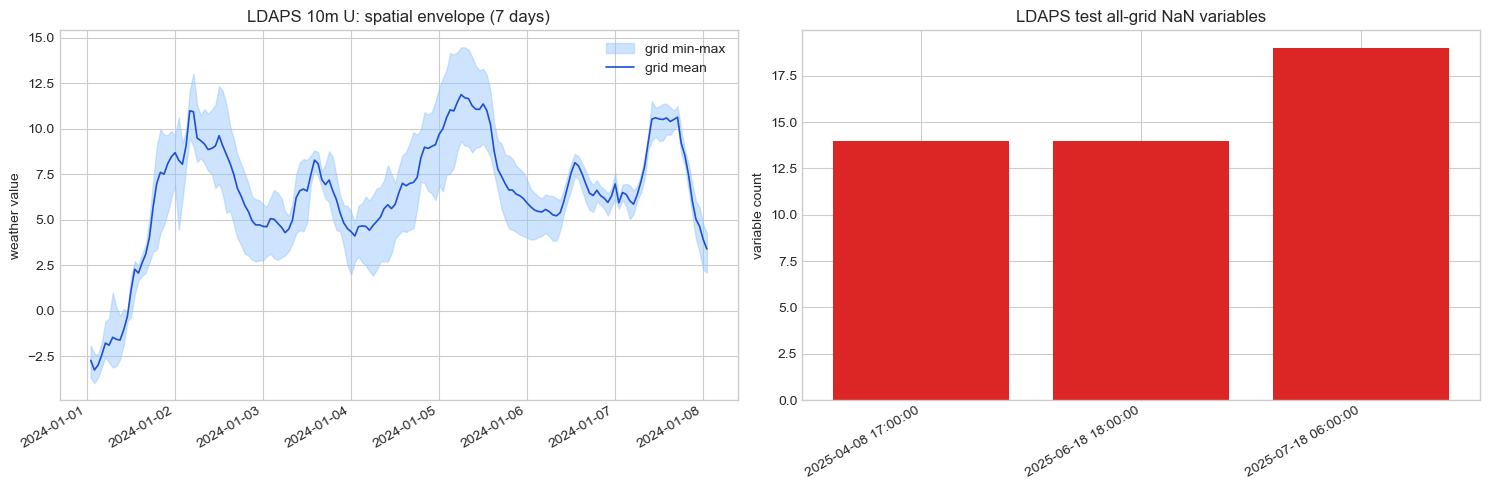

In [9]:
representativePrefix = "ldaps_heightAboveGround_10_10u"
plotStart = pd.Timestamp("2024-01-01 01:00:00")
plotEnd = plotStart + pd.Timedelta(days=7)
plotMask = expandedPair.train["forecast_kst_dtm"].between(plotStart, plotEnd)
plotFrame = expandedPair.train.loc[plotMask]
missingByTime = (
  allGridNanDetails.groupby("forecast_kst_dtm").size()
  .rename("all_grid_nan_features")
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].fill_between(
  plotFrame["forecast_kst_dtm"],
  plotFrame[f"{representativePrefix}_min"],
  plotFrame[f"{representativePrefix}_max"],
  color="#93c5fd",
  alpha=0.45,
  label="grid min-max",
)
axes[0].plot(
  plotFrame["forecast_kst_dtm"],
  plotFrame[f"{representativePrefix}_mean"],
  color="#1d4ed8",
  linewidth=1.2,
  label="grid mean",
)
axes[0].set_title("LDAPS 10m U: spatial envelope (7 days)")
axes[0].set_ylabel("weather value")
axes[0].legend()
axes[1].bar(
  missingByTime.index.astype(str),
  missingByTime.values,
  color="#dc2626",
)
axes[1].set_title("LDAPS test all-grid NaN variables")
axes[1].set_ylabel("variable count")
axes[1].tick_params(axis="x", rotation=25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 관찰 → 해석 → 다음 판단

관찰: 대표 LDAPS 바람 변수의 min-max envelope 폭은 시간에 따라 달라 mean만으로 복원할 수 없다. test all-grid NaN은 2025-04-08 17시, 06-18 18시, 07-18 06시 세 점에 집중된다.  
해석: 공간 산포는 잠재 신호이지만 결측은 source 장애의 국소 사건이다. 두 현상을 같은 0 값으로 섞으면 물리적 의미를 잃는다.  
다음 판단: NaN 보존·train median 계약을 유지한 상태에서 성능과 FICR를 비교한다.

## 5단계. 해석과 의사결정: 동일 조건 2024 holdout

| 계약 | 고정값 |
|---|---|
| split | 달력 연도 `<2024` train, `==2024` holdout; 2025-01-01 00 경계 1행 제외 |
| model/seed | 공식 RandomForest, random_state=42 |
| mask | target별 non-null train, 공식 actual ≥ 10% capacity 평가 |
| imputer | feature set별 train slice fit, validation/test transform only |
| metric | total_score, 1-NMAE, FICR, target NMAE, 6%/8% 안착률 |
| clipping | actual 원본 유지, prediction만 0~capacity |

In [10]:
validActualOriginal = trainLabels.loc[holdoutMask, TARGET_COLS].copy(deep=True)
actualHashBefore = hashlib.sha256(
  pd.util.hash_pandas_object(validActualOriginal, index=True).to_numpy().tobytes()
).hexdigest()
featureSets = {
  "official_mean": meanX,
  "expanded_spatial": expandedX,
}
modelBundles = {}
validationPredictions = {}
overallRows = []
for featureSet, fullX in featureSets.items():
  started = time.perf_counter()
  trainX = fullX.loc[modelTrainMask]
  validX = fullX.loc[holdoutMask]
  trainFrame = trainLabels.loc[modelTrainMask]
  bundle = train_random_forest_baseline(
    trainX,
    trainFrame,
    model_params=dict(OFFICIAL_RF_PARAMS),
  )
  assert np.array_equal(
    imputerObjects[featureSet].statistics_,
    bundle.imputer.statistics_,
    equal_nan=True,
  )
  predictions = predict_random_forest_baseline(bundle, validX)
  totalScore, oneMinusNmae, ficr = metric(validActualOriginal, predictions)
  modelBundles[featureSet] = bundle
  validationPredictions[featureSet] = predictions
  overallRows.append({
    "feature_set": featureSet,
    "feature_count": fullX.shape[1],
    "train_rows": int(modelTrainMask.sum()),
    "holdout_rows": int(holdoutMask.sum()),
    "total_score": float(totalScore),
    "one_minus_nmae": float(oneMinusNmae),
    "ficr": float(ficr),
    "fit_predict_seconds": time.perf_counter() - started,
  })
actualHashAfter = hashlib.sha256(
  pd.util.hash_pandas_object(validActualOriginal, index=True).to_numpy().tobytes()
).hexdigest()
assert actualHashBefore == actualHashAfter
assert all(
  bundle.train_rows[target] == int(trainLabels.loc[modelTrainMask, target].notna().sum())
  for bundle in modelBundles.values()
  for target in TARGET_COLS
)
trainingAudit = pd.DataFrame(overallRows)
display(trainingAudit)
display(pd.DataFrame({name: bundle.train_rows for name, bundle in modelBundles.items()}))

,feature_set,feature_count,train_rows,holdout_rows,total_score,one_minus_nmae,ficr,fit_predict_seconds
0,official_mean,74,17519,8784,0.576938,0.863228,0.290647,2.952286
1,expanded_spatial,271,17519,8784,0.585265,0.867325,0.303204,5.811245


,official_mean,expanded_spatial
kpx_group_1,17421,17421
kpx_group_2,17422,17422
kpx_group_3,8759,8759


### 관찰 → 해석 → 다음 판단

관찰: 두 실험 모두 같은 17,519개 학습 시간축, target별 non-null mask, 공식 RF 파라미터와 8,784시간 holdout을 사용한다. 감사용 imputer와 실제 model bundle의 median 통계가 정확히 같고 actual hash도 학습·예측 전후 동일하다.  
해석: feature set 외 조건을 고정했으므로 점수 차이는 공간 통계와 lead 추가의 결합 효과로만 해석할 수 있다.  
다음 판단: 전체 점수만 보지 않고 1-NMAE와 FICR의 교환관계, target별 NMAE와 6%/8% 안착 방향을 함께 확인한다.

In [11]:
def targetScoreRows(featureSet, actualFrame, predictionFrame):
  rows = []
  for target in TARGET_COLS:
    capacity = CAPACITY_KWH[target]
    actual = actualFrame[target].to_numpy(dtype=float)
    prediction = predictionFrame[target].to_numpy(dtype=float)
    valid = np.isfinite(actual) & (actual >= capacity * 0.10)
    errorRate = np.abs(prediction[valid] - actual[valid]) / capacity
    unitPrice = np.select(
      [errorRate <= 0.06, errorRate <= 0.08],
      [4.0, 3.0],
      default=0.0,
    )
    rows.append({
      "feature_set": featureSet,
      "target": target,
      "metric_rows": int(valid.sum()),
      "nmae": float(errorRate.mean()),
      "ficr": float(
        np.sum(actual[valid] * unitPrice) / np.sum(actual[valid] * 4.0)
      ),
      "landing_6pct": float((errorRate <= 0.06).mean()),
      "landing_8pct": float((errorRate <= 0.08).mean()),
    })
  return rows

overallScoreboard = pd.DataFrame(overallRows).set_index("feature_set")
targetScoreboard = pd.DataFrame([
  row
  for featureSet, predictions in validationPredictions.items()
  for row in targetScoreRows(featureSet, validActualOriginal, predictions)
])
overallDelta = (
  overallScoreboard.loc["expanded_spatial", ["total_score", "one_minus_nmae", "ficr"]]
  - overallScoreboard.loc["official_mean", ["total_score", "one_minus_nmae", "ficr"]]
).rename("expanded_minus_mean")
targetNmae = targetScoreboard.pivot(index="target", columns="feature_set", values="nmae")
improvedTargetCount = int(
  (targetNmae["expanded_spatial"] < targetNmae["official_mean"]).sum()
)
totalDelta = float(overallDelta["total_score"])
if totalDelta > 0 and improvedTargetCount >= 2:
  decisionStatus = "채택"
elif totalDelta > 0:
  decisionStatus = "조건부 채택"
else:
  decisionStatus = "보류"
display(overallScoreboard)
display(overallDelta.to_frame())
display(targetScoreboard)
print({
  "decision": decisionStatus,
  "total_score_delta": totalDelta,
  "targets_with_lower_nmae": improvedTargetCount,
  "actual_unchanged": actualHashBefore == actualHashAfter,
})

,feature_count,train_rows,holdout_rows,total_score,one_minus_nmae,ficr,fit_predict_seconds
feature_set,,,,,,,
official_mean,74,17519,8784,0.576938,0.863228,0.290647,2.952286
expanded_spatial,271,17519,8784,0.585265,0.867325,0.303204,5.811245


,expanded_minus_mean
total_score,0.008327
one_minus_nmae,0.004097
ficr,0.012557


,feature_set,target,metric_rows,nmae,ficr,landing_6pct,landing_8pct
0,official_mean,kpx_group_1,4989,0.129808,0.277974,0.283223,0.377430
1,official_mean,kpx_group_2,4976,0.128420,0.352206,0.306069,0.401929
2,official_mean,kpx_group_3,4566,0.152087,0.241762,0.260841,0.345817
3,expanded_spatial,kpx_group_1,4989,0.126971,0.282609,0.286631,0.380437
4,expanded_spatial,kpx_group_2,4976,0.124087,0.373646,0.323955,0.422830
5,expanded_spatial,kpx_group_3,4566,0.146965,0.253357,0.268287,0.360053


{'decision': '채택', 'total_score_delta': 0.008326982349216028, 'targets_with_lower_nmae': 3, 'actual_unchanged': True}


### 관찰 → 해석 → 다음 판단

관찰: official mean 대비 expanded는 total score `0.576938 → 0.585265`(+0.008327), 1-NMAE `0.863228 → 0.867325`(+0.004097), FICR `0.290647 → 0.303204`(+0.012557)로 모두 개선됐다. target NMAE도 Group 1 `0.129808 → 0.126971`, Group 2 `0.128420 → 0.124087`, Group 3 `0.152087 → 0.146965`로 모두 감소했다.  
해석: 개선은 한 metric의 희생으로 만든 교환이 아니라 평균오차와 정산 안착을 함께 개선한 결과다. 특히 8% 안착률은 Group 1 `0.377430 → 0.380437`, Group 2 `0.401929 → 0.422830`, Group 3 `0.345817 → 0.360053`으로 전부 상승했다.  
다음 판단: expanded를 다음 feature 기준선으로 채택하되 feature 수 74→271, fit+predict 시간이 약 3초에서 6초로 늘어난 비용과 단일 RF/2024 holdout 한계를 다음 강건성 검증 조건으로 남긴다.

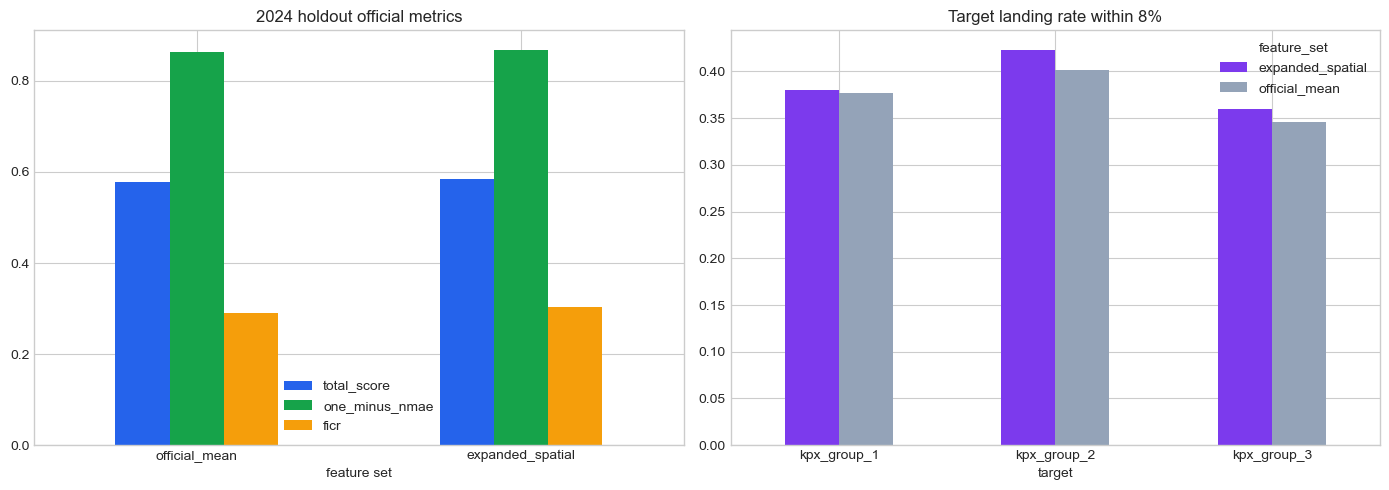

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overallScoreboard[["total_score", "one_minus_nmae", "ficr"]].plot.bar(
  ax=axes[0],
  color=["#2563eb", "#16a34a", "#f59e0b"],
)
axes[0].set_title("2024 holdout official metrics")
axes[0].set_xlabel("feature set")
axes[0].tick_params(axis="x", rotation=0)
targetLanding8 = targetScoreboard.pivot(
  index="target", columns="feature_set", values="landing_8pct"
)
targetLanding8.plot.bar(ax=axes[1], color=["#7c3aed", "#94a3b8"])
axes[1].set_title("Target landing rate within 8%")
axes[1].set_xlabel("target")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 실패 사례와 강건성 해석

| 실패·위험 | 방어 또는 해석 |
|---|---|
| metadata/cutoff/grid/lead/schema/prefix 오류 | 14개 RED→GREEN 테스트로 fail closed |
| LDAPS test 3시각 all-grid NaN | 47개 mean 결측, expanded 188개 결측을 보존한 뒤 train median |
| Group 3 구조적 label 결측 | 0 대체 없이 target별 non-null mask |
| feature 74→271 증가 | 동일 RF에서도 분할 후보 수와 일반화가 달라질 수 있어 점수와 비용을 함께 판단 |
| 단일 2024 holdout | 2025 유사성은 높지만 계절별 강건성까지 증명하지는 않음 |
| registry preprocessing 계약 | 기존 schema가 mean으로 고정되어 확장안을 거짓 등록하지 않고 이번에는 메모리 검증만 수행 |
| Windows subprocess 출력 decoding | 첫 실행에서 CP949가 pytest UTF-8 출력을 읽지 못함; `encoding='utf-8', errors='replace'`로 고정 후 재실행 |

In [13]:
validationCommands = [
  ("focused_pytest", [sys.executable, "-m", "pytest", "tests/test_weather_features.py", "-q"]),
  ("full_pytest", [sys.executable, "-m", "pytest", "-q"]),
  ("notebook_integrity", [sys.executable, "scripts/check_notebook_integrity.py"]),
]
validationRows = []
for checkName, command in validationCommands:
  completed = subprocess.run(
    command,
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
    timeout=1800,
    check=False,
  )
  combinedOutput = (
    (completed.stdout or "") + (completed.stderr or "")
  ).strip().splitlines()
  validationRows.append({
    "check": checkName,
    "returncode": completed.returncode,
    "last_line": combinedOutput[-1] if combinedOutput else "",
  })
validationResults = pd.DataFrame(validationRows)
artifactFilesAfter = snapshotArtifactFiles()
guardedArtifactsAfter = snapshotGuardedArtifacts()
newGuardedArtifacts = sorted(set(guardedArtifactsAfter) - set(guardedArtifactsBefore))
filesWritten = (
  artifactFilesAfter != artifactFilesBefore
  or bool(newGuardedArtifacts)
)
memoryContract = pd.DataFrame([
  {
    "feature_set": featureSet,
    "models_in_memory": sorted(bundle.models),
    "schema_sha256": schemaSha256(bundle.feature_columns),
    "registry_csv_written": any(
      "registry" in path.lower() and path.lower().endswith(".csv")
      for path in newGuardedArtifacts
    ),
    "model_file_written": any(
      path.lower().endswith((".pkl", ".pickle", ".joblib"))
      for path in newGuardedArtifacts
    ),
    "submission_csv_written": any(
      "submission" in path.lower() and path.lower().endswith(".csv")
      for path in newGuardedArtifacts
    ),
  }
  for featureSet, bundle in modelBundles.items()
])
display(validationResults)
display(memoryContract)
print({
  "artifact_files_before": artifactFilesBefore,
  "artifact_files_after": artifactFilesAfter,
  "guarded_artifacts_before": guardedArtifactsBefore,
  "guarded_artifacts_after": guardedArtifactsAfter,
  "new_guarded_artifacts": newGuardedArtifacts,
  "files_written": filesWritten,
})

,check,returncode,last_line
0,focused_pytest,0,[32m[32m[1m14 passed[0m[32m in 3.12s[0m[0m
1,full_pytest,0,[32m[32m[1m61 passed[0m[32m in 12.79s[0m...
2,notebook_integrity,0,노트북 무결성 검사 통과: 7개


,feature_set,models_in_memory,schema_sha256,registry_csv_written,model_file_written,submission_csv_written
0,official_mean,"[kpx_group_1, kpx_group_2, kpx_group_3]",7165ab3f8b117f90d9bbc033b2d3247bcf48d098938320...,False,False,False
1,expanded_spatial,"[kpx_group_1, kpx_group_2, kpx_group_3]",5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...,False,False,False


{'artifact_files_before': [], 'artifact_files_after': [], 'guarded_artifacts_before': [], 'guarded_artifacts_after': [], 'new_guarded_artifacts': [], 'files_written': False}


## Final Decision Box

| 결정 항목 | 실행 증거 | 판단 |
|---|---|---|
| 공식 mean 재현 | total 0.576938, 1-NMAE 0.863228, FICR 0.290647 | 기존 02 기준값과 일치 |
| expanded 전체 | total 0.585265(+0.008327), 1-NMAE +0.004097, FICR +0.012557 | **채택** |
| target NMAE | G1 -0.002837, G2 -0.004333, G3 -0.005122 | 세 그룹 모두 개선 |
| 6%/8% 안착 | 세 그룹 모두 두 임계값에서 상승 | FICR 개선과 방향 일치 |
| 전처리 안전성 | test 결측 47/188 보존 후 train median으로 0, actual hash 불변 | leakage·결측 은폐 없음 |
| 비용/한계 | feature 74→271, 단일 RF·2024 holdout | 다음 baseline으로 채택하되 최종 모델 확정은 아님 |
| 검증 | focused 14 passed, full 61 passed, 노트북 7개 무결성 통과 | GREEN |
| 산출물 안전 | `files_written=False`, 모델·registry·submission은 메모리만 | 계약 준수 |

**최종 결정:** `mean + std(ddof=0) + min + max + lead`를 다음 모델링 단계의 weather feature 기준선으로 채택한다. 공식 mean은 통제군으로 유지한다.

## 다음 판단

| 우선순위 | 후보 | 다음 검증 질문 |
|---:|---|---|
| 1 | u/v 기반 wind speed·direction | 물리 파생이 단순 축별 통계보다 target NMAE를 안정적으로 낮추는가 |
| 2 | turbine 좌표 nearest/IDW pooling | 모든 grid 동등 평균보다 발전단지 인접 격자가 유리한가 |
| 3 | 계절 fold와 GBM 민감도 | RF 한 모델·단일 holdout에서의 결론이 계절과 모델군에도 유지되는가 |

후속 후보는 우선순위만 제시하며 이 노트북에서는 시작하지 않는다. R3에 따라 Weather grid feature lab 한 작업을 완료한 뒤 정지한다.